# HR Salary Benchmarking — K-Means Clustering
### Learner Practice Notebook
**Domain:** Human Resources | **Algorithm:** K-Means | **Dataset:** 500 Employees

**Objective:**  
You will use K-Means clustering to group employees based on their experience, performance, and salary.  
Then you will identify employees who are underpaid compared to others in the same cluster.

Work through each cell step by step. Read the instructions carefully before writing your code.


## Step 1 — Import Libraries

**Instructions:**  
Import the following libraries:  
- `pandas` as `pd`  
- `numpy` as `np`  
- `matplotlib.pyplot` as `plt`  
- `KMeans` from `sklearn.cluster`  
- `StandardScaler` from `sklearn.preprocessing`  

After importing, print a confirmation message like `'All libraries imported!'`

In [1]:
# Write your import statements here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print('All libraries imported!')


All libraries imported!


## Step 2 — Load and Explore the Dataset

**Instructions:**  
Load the file `employee_data.csv` into a DataFrame called `df`.  
Then explore it:  
- Print the shape (rows and columns)  
- Display the first 10 rows  
- Check for any missing values  
- Print how many employees are in each role

In [ ]:
# Load the CSV file
df= pd.read_csv('employee_data.csv')

# Print shape
print('Shape of the dataset:', df.shape)
# Show first 10 rows
print(df.head(10))

# Check missing values
print('Missing values in each column:\n', df.isnull().sum())

# Role distribution
print('Role distribution:\n', df['role'].value_counts())


Shape of the dataset: (500, 6)
  employee_id             name             role  years_experience  \
0     EMP0001     Sneha Tiwari   Senior Analyst               5.6   
1     EMP0002      Divya Kumar  Junior Engineer               3.2   
2     EMP0003     Nikhil Mehta          Analyst               1.8   
3     EMP0004     Arjun Pillai  Junior Engineer               3.5   
4     EMP0005    Sunita Sharma  Junior Engineer               2.2   
5     EMP0006  Ananya Malhotra   Senior Analyst               7.3   
6     EMP0007     Ananya Patel        Team Lead              11.5   
7     EMP0008        Deepa Rao  Senior Engineer               8.5   
8     EMP0009       Divya Iyer        Team Lead               9.3   
9     EMP0010    Suresh Tiwari          Analyst               3.9   

   performance_score  current_salary  
0                4.2           60000  
1                2.1           39000  
2                3.9           38000  
3                2.5           55000  
4             

## Step 3 — Encode the Role Column

**Why?** K-Means only works with numbers. The `role` column has text — we need to convert it to a number that reflects seniority order.

**Instructions:**  
Create a dictionary called `role_map` that assigns a number 1 to 6 to each role, from least to most senior:  
`Analyst=1, Junior Engineer=2, Senior Analyst=3, Senior Engineer=4, Team Lead=5, Manager=6`  

Create a new column `df['role_encoded']` by mapping `df['role']` using this dictionary.  
Print the unique role-to-number mappings to verify.

In [8]:
# Define the role_map dictionary
role_map = {
    'Analyst': 1,
    'Junior Engineer': 2,
    'Senior Analyst': 3,
    'Senior Engineer': 4,
    'Team Lead': 5,
    'Manager': 6   
}

# Create role_encoded column
df['role_encoded'] = df['role'].map(role_map)

# Verify the mapping by printing unique values in role and role_encoded columns
print('Unique values in role column:', df['role'].unique())
print('Unique values in role_encoded column:', df['role_encoded'].unique())
print(df[['role', 'role_encoded']].head(10))


Unique values in role column: <StringArray>
[ 'Senior Analyst', 'Junior Engineer',         'Analyst',       'Team Lead',
 'Senior Engineer',         'Manager']
Length: 6, dtype: str
Unique values in role_encoded column: [3 2 1 5 4 6]
              role  role_encoded
0   Senior Analyst             3
1  Junior Engineer             2
2          Analyst             1
3  Junior Engineer             2
4  Junior Engineer             2
5   Senior Analyst             3
6        Team Lead             5
7  Senior Engineer             4
8        Team Lead             5
9          Analyst             1


## Step 4 — Select Features for Clustering

**Instructions:**  
Create a list called `features` containing these 4 column names:  
`'years_experience'`, `'performance_score'`, `'current_salary'`, `'role_encoded'`  

Create a DataFrame `X` by selecting only these columns from `df`.  
Print the shape of `X` and display summary statistics using `.describe()`.

In [9]:
# Define feature list
features = ['years_experience', 'performance_score', 'current_salary', 'role_encoded']

# Create X
X = df[features]

# Print shape and stats
print('Shape of X:', X.shape)
print('Statistics of X:\n', X.describe())

Shape of X: (500, 4)
Statistics of X:
        years_experience  performance_score  current_salary  role_encoded
count        500.000000          500.00000      500.000000    500.000000
mean           7.640600            3.55280    85586.000000      3.522000
std            4.338846            0.85395    37446.375874      1.715635
min            1.000000            2.00000    30000.000000      1.000000
25%            3.500000            2.80000    51000.000000      2.000000
50%            7.400000            3.55000    78500.000000      4.000000
75%           10.925000            4.30000   117250.000000      5.000000
max           18.000000            5.00000   170000.000000      6.000000


## Step 5 — Scale the Features

**Why?** `current_salary` is in tens of thousands while `performance_score` is between 2 and 5. If we don't scale, salary will dominate the distance calculation and the clustering will be biased.

**Instructions:**  
Create a `StandardScaler` object.  
Use `fit_transform()` on `X` to get `X_scaled`.  
Print the first 5 rows of `X_scaled` to see the result.

In [10]:
# Create scaler

scaler = StandardScaler()

# Fit and transform X
X_scaled = scaler.fit_transform(X)

# Print first 5 rows of X_scaled
print('First 5 rows of X_scaled:\n', X_scaled[:5])

First 5 rows of X_scaled:
 [[-0.47078043  0.75864882 -0.68395469 -0.30456527]
 [-1.0244769  -1.70297437 -1.24531827 -0.88802365]
 [-1.34746651  0.40698837 -1.27204987 -1.47148203]
 [-0.95526484 -1.23409376 -0.81761269 -0.88802365]
 [-1.25518376 -1.46853407 -1.11166027 -0.88802365]]


## Step 6 — Find the Optimal Number of Clusters using Elbow Method

**How it works:** We run K-Means for K = 1 to 10. For each K, we record the inertia (total distance of all points from their cluster centre). We plot this and look for the 'elbow' — the point where the curve bends — that is the best K.

**Instructions:**  
1. Create an empty list called `inertia`  
2. Loop through K values from 1 to 10  
3. For each K, fit a `KMeans` model on `X_scaled` and append `kmeans.inertia_` to the list  
4. Plot the elbow curve with K on X-axis and inertia on Y-axis  
5. Look at the chart and decide: what is the optimal K?

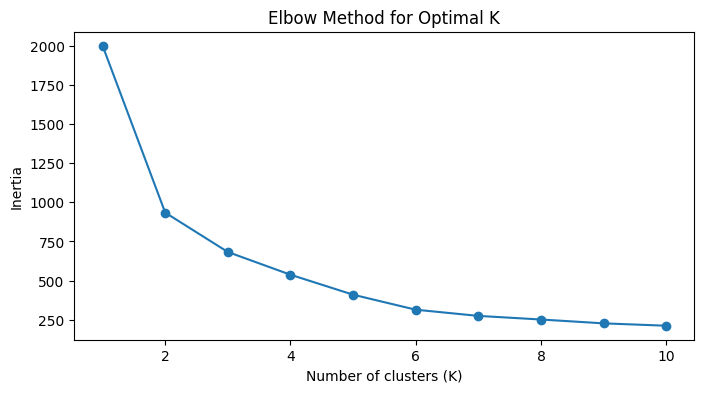

In [26]:
inertia = []
K_range = range(1, 11)

# Loop and fit KMeans for each K
for K in K_range:
    kmeans = KMeans(n_clusters=K, random_state=42)
    kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)


# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# Your answer: Optimal K = ?
optimal_k = 5


## Step 7 — Apply K-Means with Your Chosen K

**Instructions:**  
Set a variable `OPTIMAL_K` to the value you identified from the elbow chart.  
Create a `KMeans` model with `n_clusters=OPTIMAL_K` and `random_state=42`.  
Fit it on `X_scaled` and store the cluster labels in a new column `df['cluster']`.  
Print the number of employees in each cluster.

In [35]:
OPTIMAL_K = 3

# Create and fit KMeans
model = KMeans(n_clusters=OPTIMAL_K, random_state=42)
model.fit_predict(X_scaled)

# Store cluster labels in df
df['cluster'] = model.fit_predict(X_scaled)

# Print cluster distribution
print('Cluster distribution:\n', df['cluster'])


Cluster distribution:
 0      1
1      0
2      0
3      0
4      0
      ..
495    0
496    0
497    1
498    2
499    1
Name: cluster, Length: 500, dtype: int32


## Step 8 — Analyse Each Cluster

**Instructions:**  
Group `df` by `'cluster'` and calculate these aggregates:  
- Count of employees  
- Average years of experience  
- Average performance score  
- Average, min, and max salary  

Store this in a variable called `cluster_summary` and display it.  
Can you guess what type of employees each cluster represents?

In [36]:
# Group by cluster and aggregate
cluster_summary = df.groupby('cluster').agg(
    count=('cluster', 'size'),
    avg_years_experience=('years_experience', 'mean'),
    avg_performance_score=('performance_score', 'mean'),
    avg_current_salary=('current_salary', 'mean')
    
    
).round(1)

cluster_summary


,count,avg_years_experience,avg_performance_score,avg_current_salary
cluster,,,,
0,164,2.9,3.6,45902.4
1,177,7.3,3.5,80446.3
2,159,12.9,3.6,132239.0


## Step 9 — Visualise the Clusters

**Instructions:**  
Create a scatter plot with:  
- X-axis: `years_experience`  
- Y-axis: `current_salary`  
- Color: `cluster` (use `c=df['cluster']` and `cmap='tab10'`)  

Add a title, axis labels, and a colorbar.  
**Bonus:** Create a second plot with `performance_score` on the X-axis.

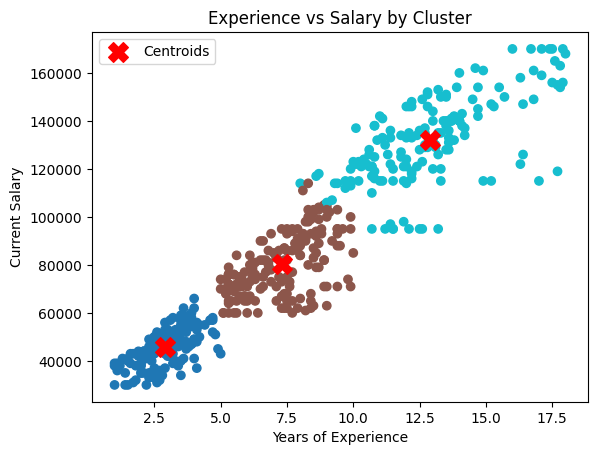

In [37]:
# Scatter plot: Experience vs Salary
plt.scatter(df['years_experience'], df['current_salary'], c=df['cluster'], cmap='tab10')
centroids = model.cluster_centers_
#print('Centroids (scaled):\n', centroids)
# Convert centroids back to original scale
centroids_original = scaler.inverse_transform(centroids)
#print('Centroids (original scale):\n', centroids_original)
plt.scatter(centroids_original[:, 0], centroids_original[:, 2], c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Years of Experience')
plt.ylabel('Current Salary')
plt.title('Experience vs Salary by Cluster')
plt.legend()
plt.show()


## Step 10 — Find Underpaid Employees

**Logic:**  
1. Compute the **median salary** for each cluster  
2. Add it as a new column `df['cluster_median_salary']`  
3. Calculate `df['salary_ratio']` = `current_salary / cluster_median_salary`  
4. Flag employees with `salary_ratio < 0.90` as underpaid in a column `df['underpaid_flag']`  
5. Filter and display the underpaid employees  

How many employees are underpaid?

In [43]:
# Step 1: Compute cluster median salary
cluster_median_salary = df.groupby('cluster')['current_salary'].median()
print('Cluster median salary:\n', cluster_median_salary)

# Step 2: Map it back to df
df['cluster_median_salary'] = df['cluster'].map(cluster_median_salary)

# Step 3: Compute salary ratio
df['salary_ratio'] = df['current_salary'] / df['cluster_median_salary']
print('First 5 rows with salary ratio:\n', df[['current_salary', 'cluster_median_salary', 'salary_ratio']].head())

# Step 4: Create underpaid flag
df['underpaid_flag'] = df['salary_ratio'] < 0.90

# Step 5: Filter and display
underpaid_employees = df[df['underpaid_flag']]
print('Underpaid employees:\n', underpaid_employees)


Cluster median salary:
 cluster
0     47000.0
1     79000.0
2    132000.0
Name: current_salary, dtype: float64
First 5 rows with salary ratio:
    current_salary  cluster_median_salary  salary_ratio
0           60000                79000.0      0.759494
1           39000                47000.0      0.829787
2           38000                47000.0      0.808511
3           55000                47000.0      1.170213
4           44000                47000.0      0.936170
Underpaid employees:
     employee_id           name             role  years_experience  \
0       EMP0001   Sneha Tiwari   Senior Analyst               5.6   
1       EMP0002    Divya Kumar  Junior Engineer               3.2   
2       EMP0003   Nikhil Mehta          Analyst               1.8   
6       EMP0007   Ananya Patel        Team Lead              11.5   
8       EMP0009     Divya Iyer        Team Lead               9.3   
..          ...            ...              ...               ...   
476     EMP0477    De

## Step 11 — Underpaid Count by Role

**Instructions:**  
From the underpaid employees DataFrame, group by `role` and count how many underpaid employees exist in each role.  
Display the result as a bar chart with appropriate title and axis labels.  

Which role has the most underpaid employees?

In [ ]:
# Group underpaid employees by role
underpaid_by_role = underpaid_employees['role'].value_counts()
print('Underpaid employees by role:\n', underpaid_by_role)

# Bar chart


Underpaid employees by role:
 role
Senior Analyst     33
Analyst            30
Team Lead          28
Senior Engineer    22
Junior Engineer    18
Manager             8
Name: count, dtype: int64


## Reflection Questions

Answer these in your own words after completing the notebook:

1. Why did we use `StandardScaler` before applying K-Means?
2. What does the elbow point in the inertia plot tell us?
3. Why is `salary_ratio < 0.90` a reasonable threshold for flagging underpaid employees?
4. How could HR use this analysis in the annual appraisal process?
5. What other features could you add to make this clustering more accurate?
